# Step 1 -  Load and EDA
- here we load the data and perfrom EDA
- for checking the null values and dtypes 

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('data.csv')
df.head()

,invoice_id,customer_id,transaction_date,product_id,quantity,unit_price,total,discount_rate,refund_flag,payment_method,country
0,INV0079407,C02045,2023-01-01,P048,2,8584,17168,0.14,0,Card,Germany
1,INV0581190,C14584,2023-01-01,P090,4,7779,31118,0.16,0,Card,UK
2,INV0410888,C10301,2023-01-01,P043,5,6183,30913,0.32,0,Card,US
3,INV0429115,C10733,2023-01-01,P085,5,14,68,0.39,0,Card,India
4,INV0020948,C00558,2023-01-01,P006,5,15309,76547,0.24,0,UPI,US


In [3]:
df.info()    # We can check Dtype and Null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 793351 entries, 0 to 793350
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   invoice_id        793351 non-null  object 
 1   customer_id       793351 non-null  object 
 2   transaction_date  793351 non-null  object 
 3   product_id        793351 non-null  object 
 4   quantity          793351 non-null  int64  
 5   unit_price        793351 non-null  int64  
 6   total             793351 non-null  int64  
 7   discount_rate     793351 non-null  float64
 8   refund_flag       793351 non-null  int64  
 9   payment_method    793351 non-null  object 
 10  country           793351 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 66.6+ MB


In [4]:
df.isnull().sum()      # To chechk null values

invoice_id          0
customer_id         0
transaction_date    0
product_id          0
quantity            0
unit_price          0
total               0
discount_rate       0
refund_flag         0
payment_method      0
country             0
dtype: int64

In [5]:
df.nunique()      # Helps to understand how many customer's  data here and same for another columns 

invoice_id          793351
customer_id          19970
transaction_date       720
product_id             100
quantity                 5
unit_price           20759
total                70391
discount_rate           41
refund_flag              2
payment_method           5
country                 10
dtype: int64

In [6]:
df.describe()   # For STD, count, mean.....

,quantity,unit_price,total,discount_rate,refund_flag
count,793351.000000,793351.000000,793351.000000,793351.000000,793351.000000
mean,3.001179,6321.968230,18964.420942,0.200107,0.055127
std,1.414622,5367.747432,19925.866928,0.115571,0.228228
min,1.000000,5.000000,5.000000,0.000000,0.000000
25%,2.000000,1879.000000,4053.000000,0.100000,0.000000
50%,3.000000,5162.000000,12487.000000,0.200000,0.000000
75%,4.000000,9683.000000,27613.000000,0.300000,0.000000
max,5.000000,21000.000000,105000.000000,0.400000,1.000000


In [7]:
# We can see that here date is in string so we have to convert it

df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Step 2 - Clean the transaction

In [8]:
df.duplicated()    # here we have no duplicates

0         False
1         False
2         False
3         False
4         False
          ...  
793346    False
793347    False
793348    False
793349    False
793350    False
Length: 793351, dtype: bool

In [9]:
df.drop_duplicates()

,invoice_id,customer_id,transaction_date,product_id,quantity,unit_price,total,discount_rate,refund_flag,payment_method,country
0,INV0079407,C02045,2023-01-01,P048,2,8584,17168,0.14,0,Card,Germany
1,INV0581190,C14584,2023-01-01,P090,4,7779,31118,0.16,0,Card,UK
2,INV0410888,C10301,2023-01-01,P043,5,6183,30913,0.32,0,Card,US
3,INV0429115,C10733,2023-01-01,P085,5,14,68,0.39,0,Card,India
4,INV0020948,C00558,2023-01-01,P006,5,15309,76547,0.24,0,UPI,US
...,...,...,...,...,...,...,...,...,...,...,...
793346,INV0347654,C08778,2024-12-20,P008,4,1399,5594,0.15,0,Card,UK
793347,INV0636071,C15947,2024-12-20,P091,5,13561,67804,0.05,0,PayPal,UK
793348,INV0135655,C03465,2024-12-20,P025,2,12339,24677,0.04,0,PayPal,UK
793349,INV0289587,C07292,2024-12-20,P001,4,11326,45305,0.11,0,Card,US


In [10]:
# here we have to create a revenue column which is IMP 

df['revenue'] = df['total'] * (1 - df['discount_rate'])

In [11]:
df = df[df['refund_flag'] == 0]         # So it removes the data who refunded so we don't have revenue of them

In [12]:
df.head()

,invoice_id,customer_id,transaction_date,product_id,quantity,unit_price,total,discount_rate,refund_flag,payment_method,country,revenue
0,INV0079407,C02045,2023-01-01,P048,2,8584,17168,0.14,0,Card,Germany,14764.48
1,INV0581190,C14584,2023-01-01,P090,4,7779,31118,0.16,0,Card,UK,26139.12
2,INV0410888,C10301,2023-01-01,P043,5,6183,30913,0.32,0,Card,US,21020.84
3,INV0429115,C10733,2023-01-01,P085,5,14,68,0.39,0,Card,India,41.48
4,INV0020948,C00558,2023-01-01,P006,5,15309,76547,0.24,0,UPI,US,58175.72


# Step 3 - Visualization & Chart's

#### Daily Revenue

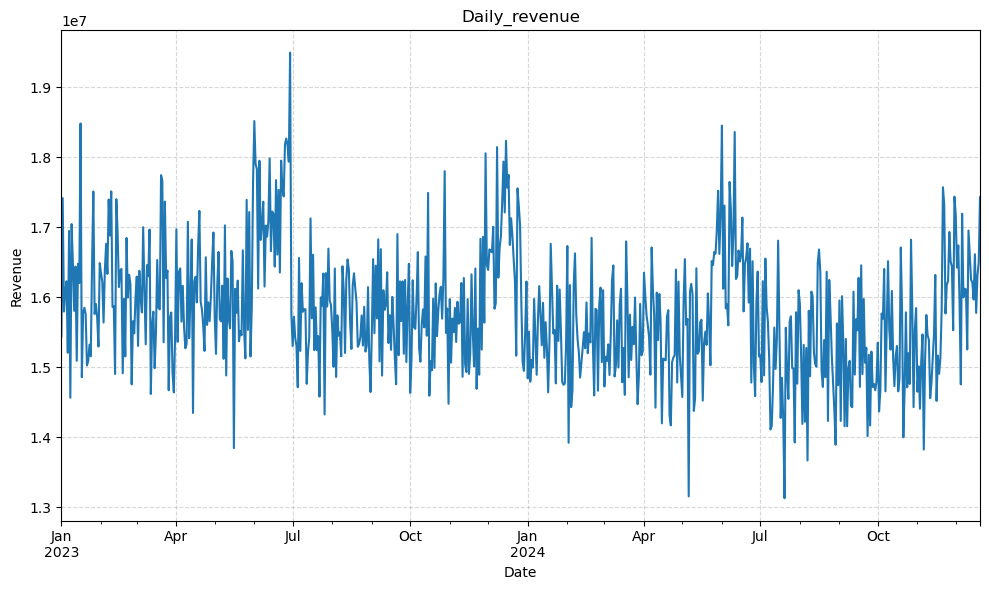

In [13]:
# Here we analyze the daily revenue trend

daily_revenue = df.resample('D', on='transaction_date')['revenue'].sum()
import matplotlib.pyplot as plt

daily_revenue.plot(figsize=(10,6))
plt.title("Daily_revenue")
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.grid(True, linestyle='--', alpha = 0.5)
plt.tight_layout()

- Daily revenue remains relatively stable between 14M–17M with occasional spikes and drops, indicating consistent business activity with periodic promotional or seasonal effects.

In [14]:
df['month'] = df['transaction_date'].dt.to_period('M')

#### Monthly_revenue

C:\Users\Farhan Diwan\AppData\Local\Temp\ipykernel_12244\2520900935.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_revenue = df.resample('M', on='transaction_date')['revenue'].sum()


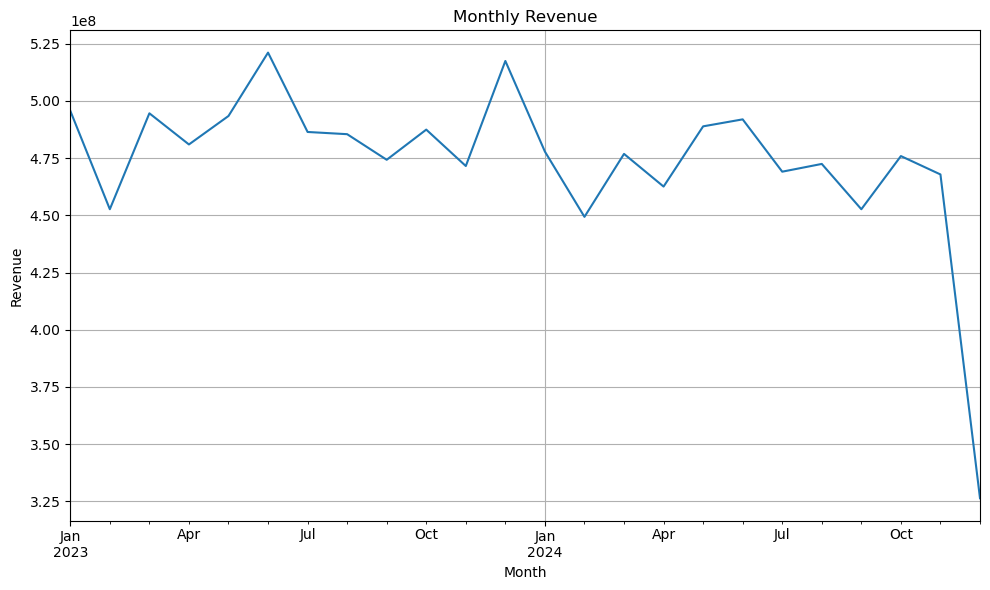

In [15]:
monthly_revenue = df.resample('M', on='transaction_date')['revenue'].sum()

monthly_revenue.plot(figsize=(10,6))
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.tight_layout()

- From this we can see that monthly revenue remains stable between 4.50 to 5 so we can see this much revenue we genrate per month
- And we can assume Peaks are seasonal and lows are non-seasonal month's

#### Top-Customer's

In [16]:
top_customers = df.groupby('customer_id')['revenue'].sum().nlargest(20)    # nlargest is FUNC. which gives mlargest 20 value

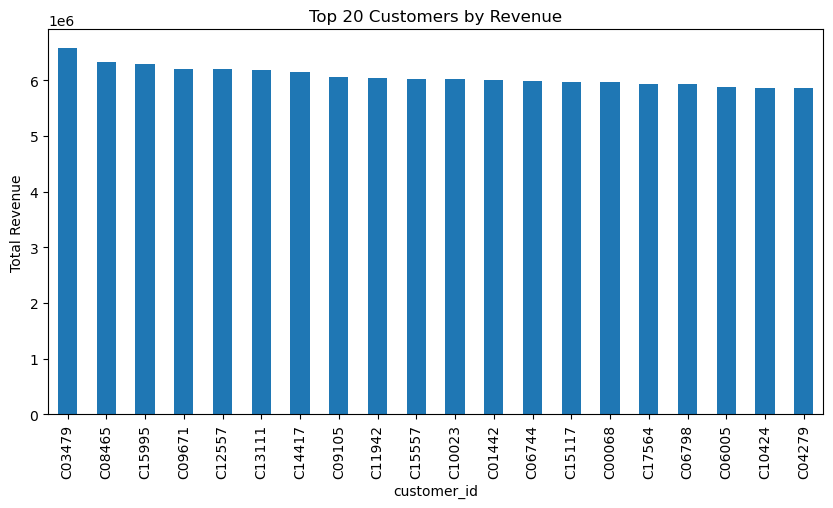

In [17]:
top_customers.plot(kind='bar', figsize=(10,5))
plt.title("Top 20 Customers by Revenue")
plt.ylabel("Total Revenue")
plt.show()

- From top customer's we can see that this cutomer's are mostly buyed from our Company

#### dicount_rate Distribution
- About 25K transactions in the dataset used a ~40% discount

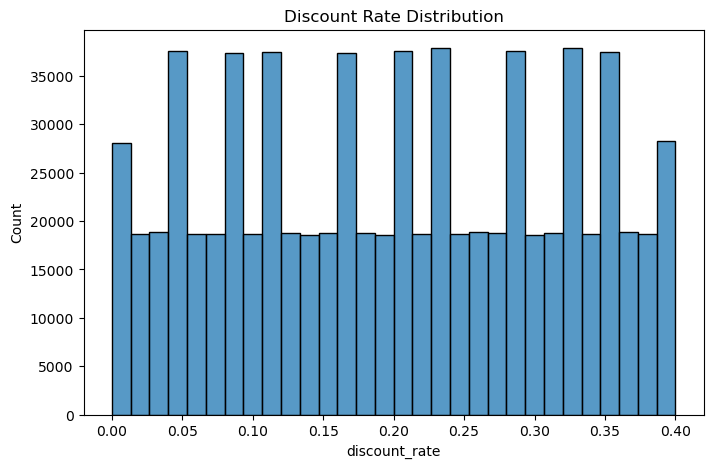

In [18]:
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(df['discount_rate'], bins=30)
plt.title("Discount Rate Distribution")
plt.show()

#### Here we can see the revenue by the payment method
- Same for the Country

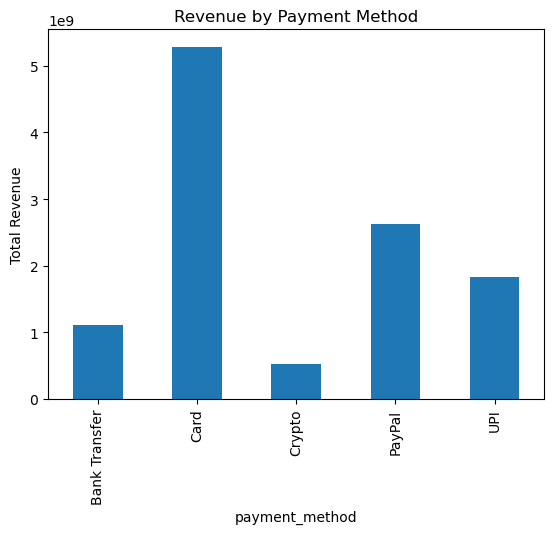

In [19]:
payment_rev = df.groupby('payment_method')['revenue'].sum()

payment_rev.plot(kind='bar')
plt.title("Revenue by Payment Method")
plt.ylabel("Total Revenue")
plt.show()

#### Revenue by country

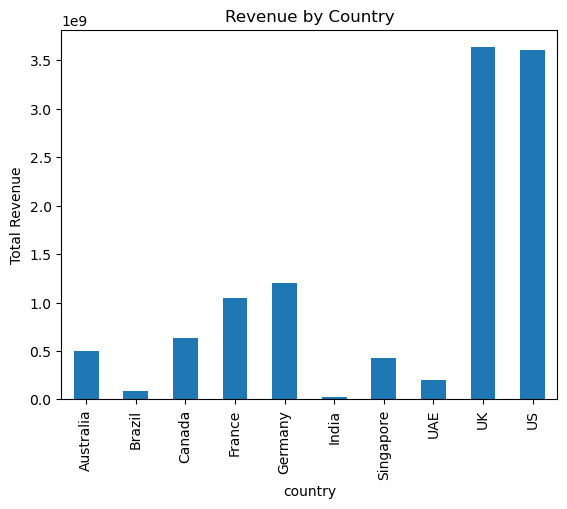

In [20]:
country_rev = df.groupby('country')['revenue'].sum()

country_rev.plot(kind='bar')
plt.title("Revenue by Country")
plt.ylabel("Total Revenue")
plt.show()

In [21]:
# Top Customer's total revenue

top_customers.max()

6584314.65

In [22]:
# Find the customer who gives us largest revenue

total_rev = df.groupby('customer_id')['revenue'].sum()
total_rev.sort_values(ascending=False)
total_rev.head(1)

customer_id
C00001    29466.26
Name: revenue, dtype: float64

In [23]:
# Most_Common discount_rate

dis = df['discount_rate'].mode()[0]      # Mode return most frequently item counts 
dis

np.float64(0.33)

In [24]:
# Top country name by revenue

top_country = country_rev.idxmax()
top_country

'UK'

# Step 4 - Define snapshot/cutoff; split past vs future

In [25]:
# First we have to short the data based on date so all months come in line

df = df.sort_values('transaction_date')

In [26]:
# Here we take 9 month for TRAINING and 3 month for TESTING
# For this we have to create a MAX_Date and CutOff_Date

In [27]:
# Max_Date and Cutoff_Date

max_date = df['transaction_date'].max()
cut_off = max_date - pd.DateOffset(months=3)           # DateOffset is FUNC... Shift a date by 3 calendar months

### Split Past vs Future - (Spliting the data based on TIME_SERIES_SPLIT) 
- Now we have to split the data bcz we do EDA ony on trainng Data
- Revenue column is needed in both bcz its our LABEL
- For Ex we have 12 month data so we take 9 = Train | 3 = Test

In [37]:
P_train = df[df['transaction_date'] < cut_off]       # Take all before the Cut_OFF
F_test = df[df['transaction_date'] >= cut_off]       # Take all after the Cut_Off

In [38]:
P_train['customer_id'].nunique()

19953

In [39]:
F_test['customer_id'].nunique()

15417

In [40]:
# This means around 4K customer's didn't buy in next 3 Months 

#### Till now we have transaction-level-dataset  but for our model 
#### we have to create customer-level-dataset from it

# Step 5 - RFM(calculations) | Customer-level-dataset
- we do this only on the Training dataset
- if we do this on test also its a data LEAKAGE

In [44]:
# In this we have to create customer data so we always work on GROUPBY('customer_id')

group = P_train.groupby('customer_id')    # So we create it in variable

#### We have to define the snapshot date 
- very imp to calculate RFM
- Last purchase date/

In [45]:
snap_date = P_train['transaction_date'].max()
snap_date

Timestamp('2024-09-19 00:00:00')

### Recency = means gap between today and its last purchase 
- In this we have to find the lateste purchase date from snapshot_date
- Here we always grouped the customer_id bcz we're creating customer_data

In [95]:
recency = (snap_date - group['transaction_date'].max()).dt.days

recency.isnull().sum()

np.int64(0)

### Frequency - how many time 1 customer buy's
- Higher frequency → higher probability of future purchases

In [96]:
frequency = group['invoice_id'].nunique()

frequency.isnull().sum()

np.int64(0)

### Monetary = Total revenue generated by a customer before the snapshot date
- Monetary = Sum of transaction totals

In [97]:
m_value = group['revenue'].sum()

m_value.isnull().sum()

np.int64(0)

### AOV(Average order value) 
- How much does this customer typically spend when they buy?
- AOV = Total money spent / Number of orders

In [98]:
aov = m_value / frequency

aov.isnull().sum()

np.int64(0)

### Tenure 
- How long has this customer been with us?
- Tenure = Number of days between the snapshot date and the customer's first purchase
- Tenure = Last Purchase Date − First Purchase Date
- High tenure → long-term customer
- Low tenure → new customer

In [99]:
tenure = (group['transaction_date'].max() - group['transaction_date'].min()).dt.days

tenure.isnull().sum()

np.int64(0)

### Revenue last 30 day's

In [100]:
cutoff_30 = P_train['transaction_date'].max() - pd.Timedelta(days=30)        # Timedelta is FUNC..... same as .DateOffset

rev_30 =  (P_train[P_train['transaction_date'] >= cutoff_30].groupby('customer_id')['revenue'].sum())         # TD > CUT...... we want next data from CUT

rev_30.isnull().sum()

np.int64(0)

### Revenue last 30 day's

In [101]:
cutoff_90 = P_train['transaction_date'].max() - pd.Timedelta(days=90)            # Timedelta = Day's   |    DateOffset = Month's

rev_90 = (P_train[X_train['transaction_date'] >= cutoff_90].groupby('customer_id')['revenue'].sum())

rev_90.isnull().sum()

np.int64(0)

### Order's in last 30 day's

In [72]:
order_30 = P_train[P_train['transaction_date'] >= cutoff_30].groupby('customer_id')['invoice_id'].nunique()

### Order's in last 90 day's

In [75]:
order_90 = P_train[P_train['transaction_date'] >= cutoff_90].groupby('customer_id')['invoice_id'].nunique()

### Purchase_velocity = frequency / tenure
- means how fast a customer place order 
- like F=2 and T=10  so it order's in 5 days

In [115]:
purchase_velocity = (frequency / tenure.replace(0,1)).round(4)

### Purchase Trend
- purchase_trend = revenue_last_30_days / revenue_last_90_days
- whether spending is growing or declining

In [116]:
purchase_trend = rev_30.div(rev_90.replace(0,1), fill_value=0)

In [125]:
mean_disc = (P_train.groupby("customer_id")["discount_rate"].mean())

## Create customer DataFrame

In [119]:
customer_df = pd.DataFrame({
    'recency': recency,
    'frequency': frequency,
    'monetary': m_value,
    'aov': aov,
    'tenure': tenure,
    'revenue_last_30_days': rev_30,
    'revenue_last_90_days': rev_90,
    'orders_last_30_days': order_30,
    'orders_last_90_days': order_90,
    'purchase_velocity': purchase_velocity
})

# replace missing activity with 0
customer_df = customer_df.fillna(0)

# compute trend safely
customer_df["purchase_trend"] = (
    customer_df["revenue_last_30_days"] /
    customer_df["revenue_last_90_days"].replace(0,1)
)

In [130]:
customer_df =  customer_df.reset_index()
customer_df["mean_discount"] = (
    customer_df["customer_id"].map(mean_disc).fillna(0)
)

In [131]:
customer_df

,customer_id,recency,frequency,monetary,aov,tenure,revenue_last_30_days,revenue_last_90_days,orders_last_30_days,orders_last_90_days,purchase_velocity,purchase_trend,mean_discount
0,C00001,420,3,26120.41,8706.803333,182,0.00,0.00,0.0,0.0,0.0165,0.000000,0.250000
1,C00002,20,34,122072.20,3590.358824,599,1468.94,8220.64,2.0,4.0,0.0568,0.178689,0.215294
2,C00003,59,4,9363.40,2340.850000,288,0.00,2127.20,0.0,1.0,0.0139,0.000000,0.252500
3,C00004,539,2,3139.84,1569.920000,66,0.00,0.00,0.0,0.0,0.0303,0.000000,0.375000
4,C00005,51,9,26944.34,2993.815556,446,0.00,646.40,0.0,1.0,0.0202,0.000000,0.146667
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19948,C19996,224,5,29679.04,5935.808000,390,0.00,0.00,0.0,0.0,0.0128,0.000000,0.098000
19949,C19997,16,29,321439.98,11084.137241,604,21617.88,49593.28,2.0,4.0,0.0480,0.435903,0.205172
19950,C19998,448,4,24246.94,6061.735000,172,0.00,0.00,0.0,0.0,0.0233,0.000000,0.225000
19951,C19999,0,26,181921.67,6996.987308,615,3219.43,18060.70,1.0,4.0,0.0423,0.178256,0.198077


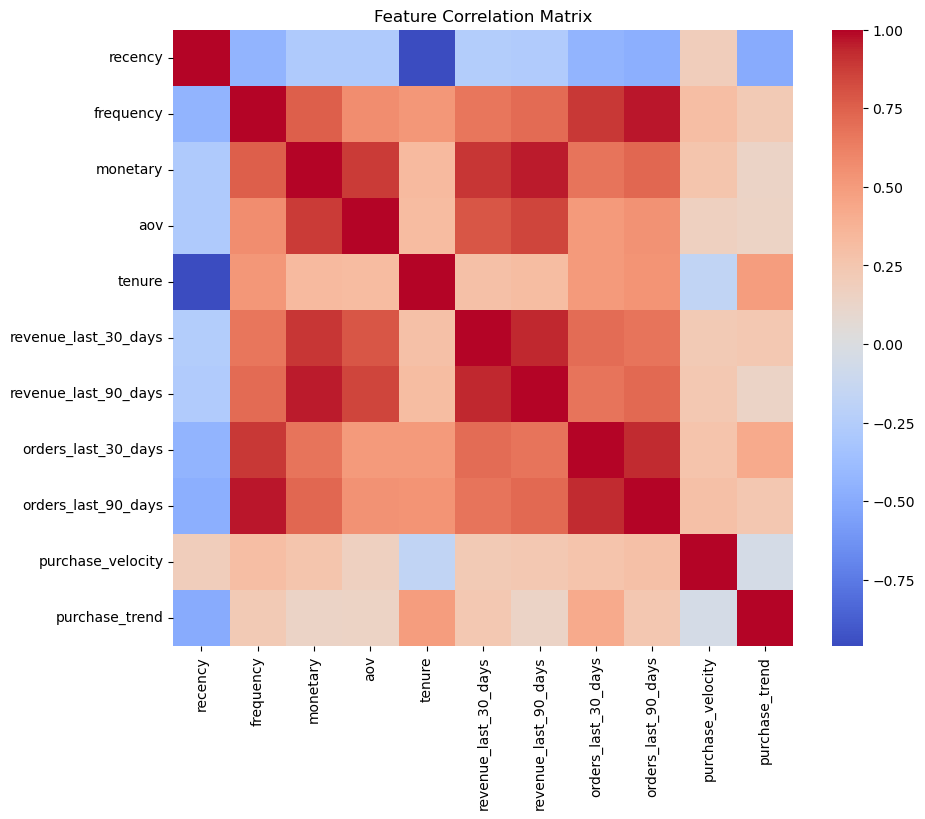

In [121]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    customer_df.corr(numeric_only=True),
    annot=False,
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")
plt.show()